In [1]:
import os
import time
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
import MGLensing
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy import integrate
from copy import deepcopy


import pyccl as ccl

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

PyHMCode not installed!
PyHMCode not installed!
euclidlib not installed! Euclid TR1 setup will not be available!
/Users/s2265800/Desktop/GitHub/MGlensing/MGLensing


In [2]:
# switch to the main directory
# change this to your path of the MGlensing repository
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

# Survey
LSST Y1 setup

In [3]:
kmax07 = [478, 617, 716, 780, 818]


MGL = MGLensing.MGL("ini_files/config_files/config_bacco.yaml")
# MGL Cells 
ell_l = MGL.Survey.l_wl
ell_g = MGL.Survey.l_gc
ell_x = MGL.Survey.l_xc
zz_integr = MGL.Survey.zz_integr  #512 points for better agreement
dndz_sources = MGL.Survey.eta_z_s
dndz_lenses = MGL.Survey.eta_z_l
nbin_l = MGL.Survey.nbin_l
nbin_s = MGL.Survey.nbin_s

# set IA to 0
params = {'Omega_m' : 0.31,
    'Omega_c'   : 0.31-0.05,
    'Omega_cb'  : 0.31,
    'sigma8_cb' : 0.83,
    # 'As'      : np.exp(3.07)*1.e-10,
    'Omega_b'   : 0.05,
    'ns'        : 0.96,
    'h'         : 0.68,
    'Mnu'       : 0.,
    'w0'        : -1.0,
    'wa'        : 0.0, 
    'b1L_1': 0.187684,
    'b1L_2': 0.312375,
    'b1L_3': 0.45121,
    'b1L_4': 0.60626,
    'b1L_5': 0.779385,
    'b2L_1': -0.1322075,
    'b2L_2': -0.0345375,
    'b2L_3': 0.0579305,
    'b2L_4': 0.133662,
    'b2L_5': 0.232387,
    'bs2L_1': 0.1127485,
    'bs2L_2': 0.0036835,
    'bs2L_3': -0.1261985,
    'bs2L_4': -0.285537,
    'bs2L_5': -0.406101,
    'blaplL_1': -0.100126,
    'blaplL_2': -0.1563475,
    'blaplL_3': -0.115281,
    'blaplL_4': 0.1059295,
    'blaplL_5': 0.361450,
    'a1_IA'   : 0., #0.16,
    'eta1_IA' : 0., #1.66,
    'beta_IA' : 0.,
}     


# first call MGL
NL_MODEL_HMCODE = 0
NL_MODEL_BACCO = 1

NO_BARYONS = 0
BARYONS_HMCODE = 1
BARYONS_BCEMU = 2
BARYONS_BACCO = 3

BIAS_LIN = 0
BIAS_B1B2 = 1
BIAS_HEFT = 2

model = {
    'nl_model' : 1,
    'bias_model' : 2,
    'baryon_model' : 0,
    'ia_model' : 0,
    'photoz_err_model' : 0,
    'heft_extrap_k_const': False
}


Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonli

# Power spectrum comparison

In [4]:
# MGL power spectra
k_arr, pmm_mgl, pgm_mgl, pgg_mgl = MGL.get_power_spectra(params, model)

# CCL initialization
bemu_nl = ccl.BaccoemuNonlinear()
cosmo_nl = ccl.Cosmology(Omega_c=params['Omega_c'], 
                         Omega_b=params['Omega_b'], 
                         h=params['h'], 
                         n_s=params['ns'], 
                         sigma8=params['sigma8_cb'],
                        #  A_s=params['As'],
                         m_nu=params['Mnu'], 
                         w0=params['w0'],
                         wa=params['wa'],
                         transfer_function='boltzmann_camb',
                         matter_power_spectrum=bemu_nl
                         )

# CCL non linear matter power spectrum with Bacco
pk_nl_bemu = cosmo_nl.get_nonlin_power()

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory

In [5]:
_, rcom = MGL.get_expansion_and_rcom(params)
# pick 3 redshifts
z_int_pick = [60, 100, 120] #goes from 0 to 399
def k2ell(x, ind=z_int_pick[0]):
    return x*rcom[ind]-0.5
def ell2k(x, ind=z_int_pick[0]):
    return (x+0.5)/rcom[ind]
def k2ell1(x, ind=z_int_pick[1]):
    return x*rcom[ind]-0.5
def ell2k1(x, ind=z_int_pick[1]):
    return (x+0.5)/rcom[ind]
def k2ell2(x, ind=z_int_pick[2]):
    return x*rcom[ind]-0.5
def ell2k2(x, ind=z_int_pick[2]):
    return (x+0.5)/rcom[ind]
f_arr = [k2ell, k2ell1, k2ell2]
f_inv_arr = [ell2k, ell2k1, ell2k2]
# pick the bins
bin_i=2
bin_j=3

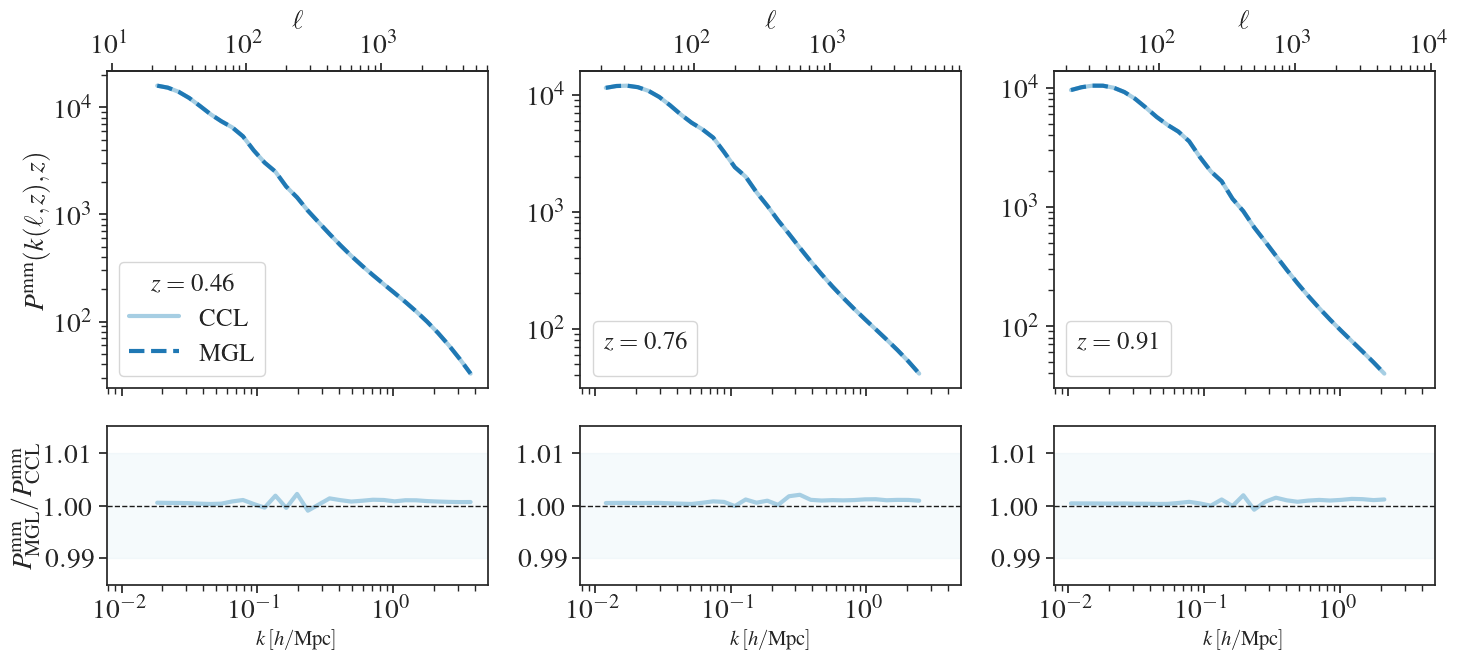

In [ ]:
z_indices = z_int_pick
a_z = []
for z in z_indices:
    a_z.append(1 / (1 + zz_integr[z]))

fig, ax = plt.subplots(2, 3, figsize=(15, 7), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for i in range(len(z_indices)):
    k = k_arr[:,z_indices[i]]
    pmm_nl_ccl = pk_nl_bemu(k*params['h'], a_z[i], cosmo_nl)* params['h']**3
    ax[0][i].loglog(k, pmm_nl_ccl, color='C0', label='CCL' if i == 0 else '') 
    ax[0][i].loglog(k, pmm_mgl[:,z_indices[i]], color='C1', linestyle='--', label='MGL' if i == 0 else '') 
    ax[0][i].legend(title=f'$z={zz_integr[z_int_pick[i]]:.2f}$', loc='lower left', frameon=True, title_fontsize=18)
    secax = ax[0][i].secondary_xaxis('top', functions=(f_arr[i], f_inv_arr[i]))
    secax.set_xlabel('$\ell$')

    ax[1][i].plot(k, pmm_mgl[:,z_indices[i]]/pmm_nl_ccl, color='C0')
    ax[1][i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
    ax[1][i].set_xlabel(r'$k\, [h/\rm Mpc]$', fontsize=15)
    ax[1][i].axhspan(0.99, 1.01, color='C0', alpha=0.1, label='_nolegend_')
    ax[1][i].set_ylim(0.985, 1.015)


ax[0][0].set_ylabel("$P^{\\rm mm}(k(\ell, z), z)$")
ax[1][0].set_ylabel("$P^{\\rm mm}_{\\rm MGL}/P_{\\rm CCL}^{\\rm mm}$")
plt.tight_layout()

# Galaxy power spectrum

In [7]:
h = params['h']
min_k = np.log10(2.e-4 * h)  # from MGL bacco_interface
#max_k = np.log10(0.7 * h)
max_k = np.log10(0.75 * h)
# with Bacco HEFT 
heft = ccl.nl_pt.BaccoLbiasCalculator(cosmo=cosmo_nl, log10k_min=min_k, log10k_max=max_k, nk_per_decade=512)
heft.update_ingredients(cosmo_nl)


b1L = np.array([params[f'b1L_{i+1}']+1 for i in range(nbin_l)])
b2L = np.array([params[f'b2L_{i+1}']*2 for i in range(nbin_l)])
bs2 = np.array([params[f'bs2L_{i+1}']*2 for i in range(nbin_l)])
bLap = np.array([params[f'blaplL_{i+1}']*2 for i in range(nbin_l)])

bias_ia = params['a1_IA'] * (1.+zz_integr)**params['eta1_IA'] * 0.0134/0.01387684609

# get HEFT Pgg
pk_gg_ccl = [[None for j in range(nbin_l)] for i in range(nbin_l)]
pk_gm_ccl = [[None for j in range(nbin_s)] for i in range(nbin_l)]
for i in range(nbin_l):
    for j in range(nbin_l):
        ptt_lens_i = ccl.nl_pt.PTNumberCountsTracer(b1=(zz_integr, b1L[i]*np.ones(len(zz_integr))), b2=(zz_integr, b2L[i]*np.ones(len(zz_integr))), 
                                            bs=(zz_integr, bs2[i]*np.ones(len(zz_integr))), bk2=(zz_integr, bLap[i]*np.ones(len(zz_integr))))
        ptt_lens_j = ccl.nl_pt.PTNumberCountsTracer(b1=(zz_integr, b1L[j]*np.ones(len(zz_integr))), b2=(zz_integr, b2L[j]*np.ones(len(zz_integr))), 
                                    bs=(zz_integr, bs2[j]*np.ones(len(zz_integr))), bk2=(zz_integr, bLap[j]*np.ones(len(zz_integr))))
        pk_gg_ccl[i][j] = heft.get_biased_pk2d(tracer1=ptt_lens_i, tracer2=ptt_lens_j)


for i in range(nbin_l):
    for j in range(nbin_s):
        ptt_lens_i = ccl.nl_pt.PTNumberCountsTracer(b1=(zz_integr, b1L[i]*np.ones(len(zz_integr))), b2=(zz_integr, b2L[i]*np.ones(len(zz_integr))), 
                                            bs=(zz_integr, bs2[i]*np.ones(len(zz_integr))), bk2=(zz_integr, bLap[i]*np.ones(len(zz_integr))))
        ptt_source_j = ccl.nl_pt.PTMatterTracer()
        
        pk_gm_ccl[i][j] = heft.get_biased_pk2d(tracer1=ptt_lens_i, tracer2=ptt_source_j)

Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.


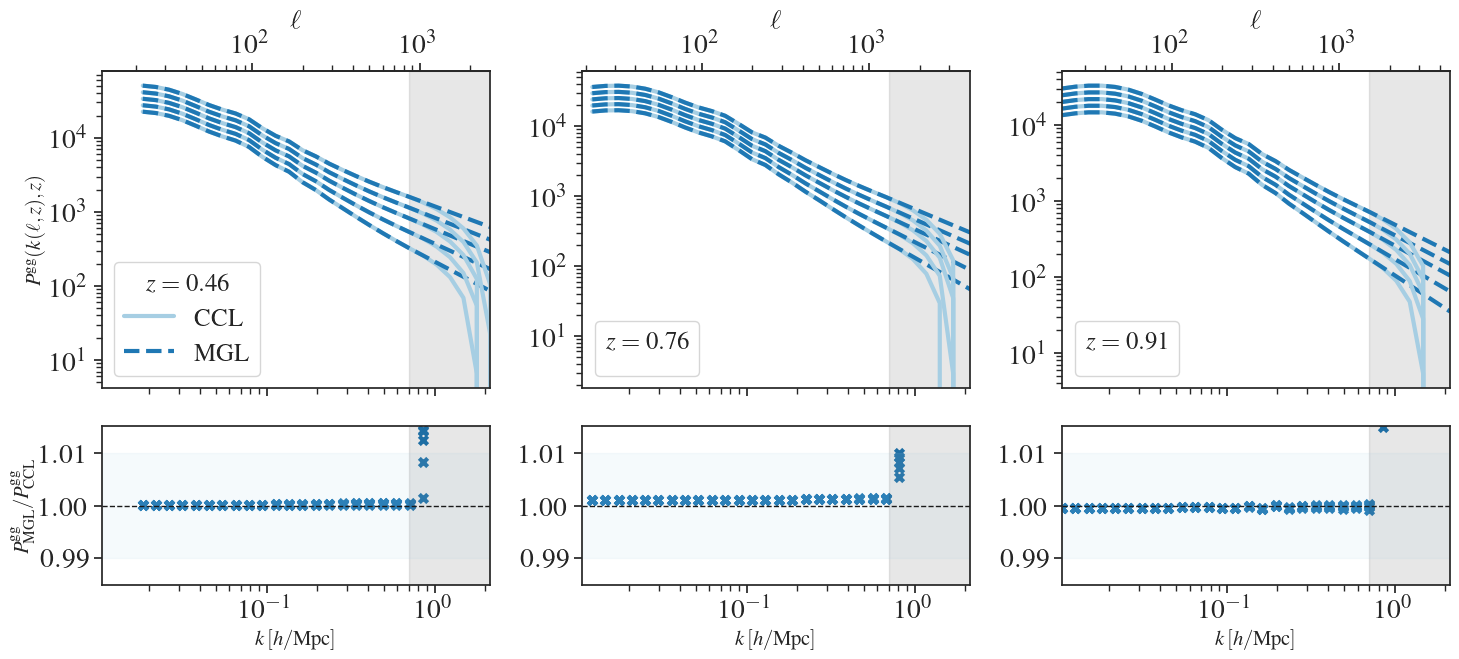

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for z in range(len(z_indices)):
    k = k_arr[:,z_indices[z]]
    for i in range(nbin_l):
        pgg_ccl = pk_gg_ccl[i][i](k*params['h'], a_z[z], cosmo_nl)* params['h']**3
        ax[0][z].loglog(k, pgg_ccl, color='C0', label='CCL' if i == 0 and  z == 0 else '')
        ax[0][z].loglog(k, pgg_mgl[:,z_indices[z],i,i], color='C1', linestyle='--', label='MGL' if i == 0 and  z == 0 else '')
        #
        ax[1][z].scatter(k, pgg_mgl[:,z_indices[z],i,i]/pgg_ccl, color='C1', marker='x')
        
    ax[0][z].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[0][z].legend(title=f'$z={zz_integr[z_int_pick[z]]:.2f}$', loc='lower left', frameon=True, title_fontsize=18)
    secax = ax[0][z].secondary_xaxis('top', functions=(f_arr[z], f_inv_arr[z]))
    secax.set_xlabel('$\ell$')
    ax[1][z].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
    ax[1][z].set_xlabel(r'$k\, [h/\rm Mpc]$', fontsize=15)
    ax[1][z].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[1][z].axhspan(0.99, 1.01, color='C0', alpha=0.1, label='_nolegend_')
    ax[1][z].set_xlim(k[0], k[-1])
    ax[1][z].set_ylim(0.985, 1.015)

ax[0][0].set_ylabel("$P^{\\rm gg}(k(\ell, z), z)$", fontsize=15)
ax[1][0].set_ylabel("$P^{\\rm gg}_{\\rm MGL}/P_{\\rm CCL}^{\\rm gg}$", fontsize=15)
plt.tight_layout()

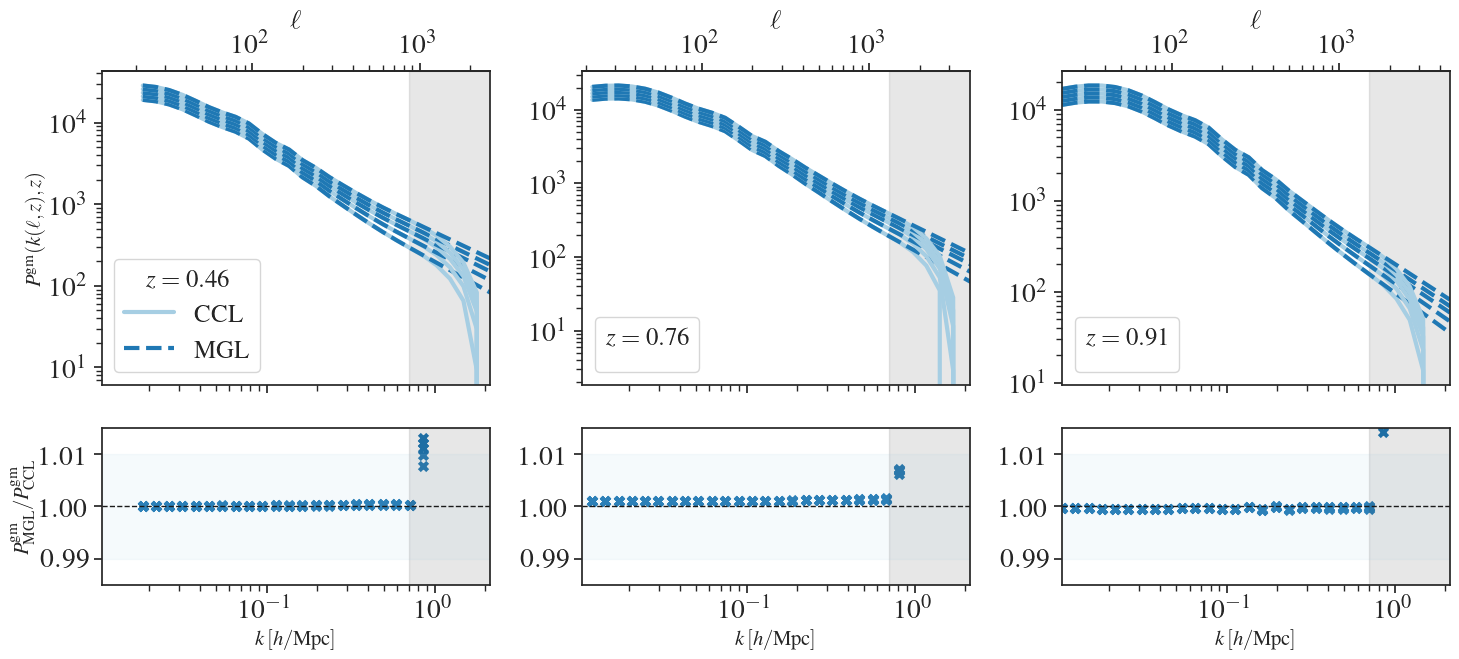

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7), facecolor='w', gridspec_kw={'height_ratios':[2,1] }, sharex=True)
for z in range(len(z_indices)):
    k = k_arr[:,z_indices[z]]
    for i in range(nbin_l):
        pgm_ccl = pk_gm_ccl[i][0](k*params['h'], a_z[z], cosmo_nl)* params['h']**3 #second index can be any source-bin
        ax[0][z].loglog(k, pgm_ccl, color='C0', label='CCL' if i == 0 and  z == 0 else '')
        ax[0][z].loglog(k, pgm_mgl[:,z_indices[z],i], color='C1', linestyle='--', label='MGL' if i == 0 and  z == 0 else '')
        #
        ax[1][z].scatter(k, pgm_mgl[:,z_indices[z],i]/pgm_ccl, color='C1', marker='x')
        
    ax[0][z].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[0][z].legend(title=f'$z={zz_integr[z_int_pick[z]]:.2f}$', loc='lower left', frameon=True, title_fontsize=18)
    secax = ax[0][z].secondary_xaxis('top', functions=(f_arr[z], f_inv_arr[z]))
    secax.set_xlabel('$\ell$')
    ax[1][z].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
    ax[1][z].set_xlabel(r'$k\, [h/\rm Mpc]$', fontsize=15)
    ax[1][z].axvspan(0.7, k[-1], color='k', alpha=0.1, label='_nolegend_')
    ax[1][z].axhspan(0.99, 1.01, color='C0', alpha=0.1, label='_nolegend_')
    ax[1][z].set_xlim(k[0], k[-1])
    ax[1][z].set_ylim(0.985, 1.015)

ax[0][0].set_ylabel("$P^{\\rm gm}(k(\ell, z), z)$", fontsize=15)
ax[1][0].set_ylabel("$P^{\\rm gm}_{\\rm MGL}/P_{\\rm CCL}^{\\rm gm}$", fontsize=15)
plt.tight_layout()

# Redshift distribution and kernels

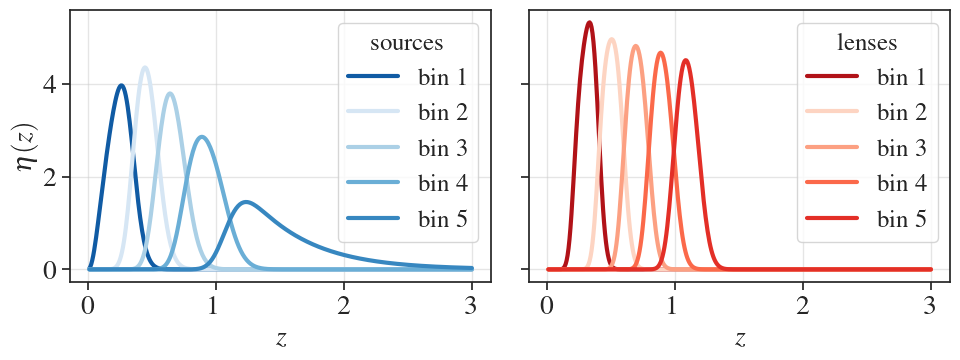

In [10]:
etaz = [MGL.Survey.eta_z_s, MGL.Survey.eta_z_l]
titles = ['sources', 'lenses']
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for k in range(2):
    for i in range(etaz[k].shape[1]):
        ax[k].plot(zz_integr, etaz[k][:, i], label='bin ' + str(i + 1), color=sns.color_palette("Blues", 5)[i-1] if k==0 else sns.color_palette("Reds", 5)[i-1])
    ax[k].set_xlabel("$z$")
    ax[k].legend(loc='upper right', title=titles[k], title_fontsize=18)
    ax[k].grid(alpha=0.5)
ax[0].set_ylabel("$\\eta(z)$")
plt.tight_layout()

In [11]:
bias_ia = params['a1_IA'] * (1.+zz_integr)**params['eta1_IA'] * 0.0134/0.01387684609

bias_g = np.ones_like(zz_integr)

# define tracers
lenses_ccl = [ccl.NumberCountsTracer(
            cosmo_nl, has_rsd=False, dndz=(zz_integr, dndz_lenses[:,i]), 
            bias=(zz_integr, bias_g), mag_bias=None)
       for i in range(nbin_l)]
sources_ccl = [ccl.WeakLensingTracer(
            cosmo_nl, dndz=(zz_integr, dndz_sources[:,i]), ia_bias=(zz_integr, bias_ia))
       for i in range(nbin_s)]


In [12]:
W_WL, W_IA, W_GC = MGL.get_windows(params, model)

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory

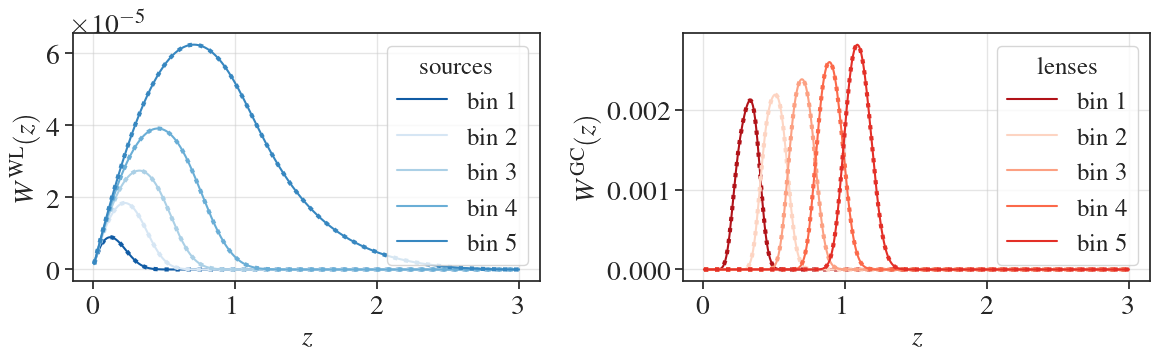

In [13]:
titles = ['sources', 'lenses']
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for k in range(2):
    for i in range(etaz[k].shape[1]):
        if k==0:
            ax[k].plot(zz_integr, W_WL[0, :, i], label='bin ' + str(i + 1), color=sns.color_palette("Blues", 5)[i-1],linewidth=1.5)
            ax[k].plot(zz_integr, sources_ccl[i].get_kernel(rcom/params['h'])[0]/params['h'], color=sns.color_palette("Blues", 5)[i-1], ls=':')
        else:
            ax[k].plot(zz_integr, W_GC[0 ,:, i], label='bin ' + str(i + 1), color=sns.color_palette("Reds", 5)[i-1],linewidth=1.5)
            ax[k].plot(zz_integr, lenses_ccl[i].get_kernel(rcom/params['h'])[0]/params['h'], color=sns.color_palette("Reds", 5)[i-1], ls=':')        
    ax[k].set_xlabel("$z$")
    ax[k].grid(alpha=0.5)
    ax[k].legend(loc='upper right', title=titles[k], title_fontsize=18)
ax[0].set_ylabel("$W^{\\rm WL}(z)$")
ax[1].set_ylabel("$W^{\\rm GC}(z)$")
plt.tight_layout()

# Angular power spectra

In [14]:
# Cells with MGL
cl_wl_mgl, cl_gc_mgl, cl_sourcelens_mgl, cl_lenssource_mgl = MGL.get_c_ells(params, model)
#errorbars are computed from the data defined in cofig-file
#you can change values of the parameters but not the modelling
err_cl_wl, err_cl_gc, err_cl_xc = MGL.get_errorbars(params) #err_cl_xc=err_cl_lenssource

# get CCL Cells with HEFT Pgg
cl_wl_ccl = np.zeros((len(ell_l), nbin_s, nbin_s))
cl_gc_ccl = np.zeros((len(ell_g), nbin_l, nbin_l))
cl_lenssource_ccl = np.zeros((len(ell_x), nbin_l, nbin_s))
cl_sourcelens_ccl = np.zeros((len(ell_x), nbin_s, nbin_l))
# compute angular power spectra
for i in range(nbin_l):
    for j in range(nbin_l):
        cl_gc_ccl[:,i,j] = ccl.angular_cl(cosmo_nl, lenses_ccl[i], lenses_ccl[j], ell_g, p_of_k_a=pk_gg_ccl[i][j])

for i in range(nbin_s):
    for j in range(nbin_s):
        cl_wl_ccl[:,i,j] = ccl.angular_cl(cosmo_nl, sources_ccl[i], sources_ccl[j], ell_l)

for i in range(nbin_s):
    for j in range(nbin_l):
        cl_sourcelens_ccl[:,i,j] = ccl.angular_cl(cosmo_nl, sources_ccl[i], lenses_ccl[j], ell_x, p_of_k_a=pk_gm_ccl[j][i])
      

for i in range(nbin_l):
    for j in range(nbin_s):
        cl_lenssource_ccl[:,i,j] = ccl.angular_cl(cosmo_nl, lenses_ccl[i], sources_ccl[j], ell_x, p_of_k_a=pk_gm_ccl[i][j])        

# add noise to diagonal components (noise=0 for WLxGC)
for i in range(nbin_s):
    cl_wl_ccl[:,i,i] += MGL.Survey.noise['LL']
for i in range(nbin_l):
    cl_gc_ccl[:,i,i] += MGL.Survey.noise['GG']

model["nl_model"] =  1
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory.
Loading Baryonic Emulator...
Baryonic Emulator loaded in memory.
Loading l-bias lpt emulator...
L-bias lpt emulator loaded in memory.
Loading smeared bao emulator...
Smeared bao emulator loaded in memory.
Loading non-linear l-bias emulator...
Nonlinear l-bias emulator loaded in memory.
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
initialising baccoemu
Loading sigma8 emulator...
Sigma8 emulator loaded in memory.
Loading linear emulator...
Linear emulator loaded in memory.
Loading no-wiggles emulator...
No-wiggles emulator loaded in memory.
Loading non-linear emulator...
Nonlinear emulator loaded in memory

In [15]:
# sanity check
cl_sourcelens_ccl[:, 0, 1]/cl_lenssource_ccl[:, 1, 0]

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

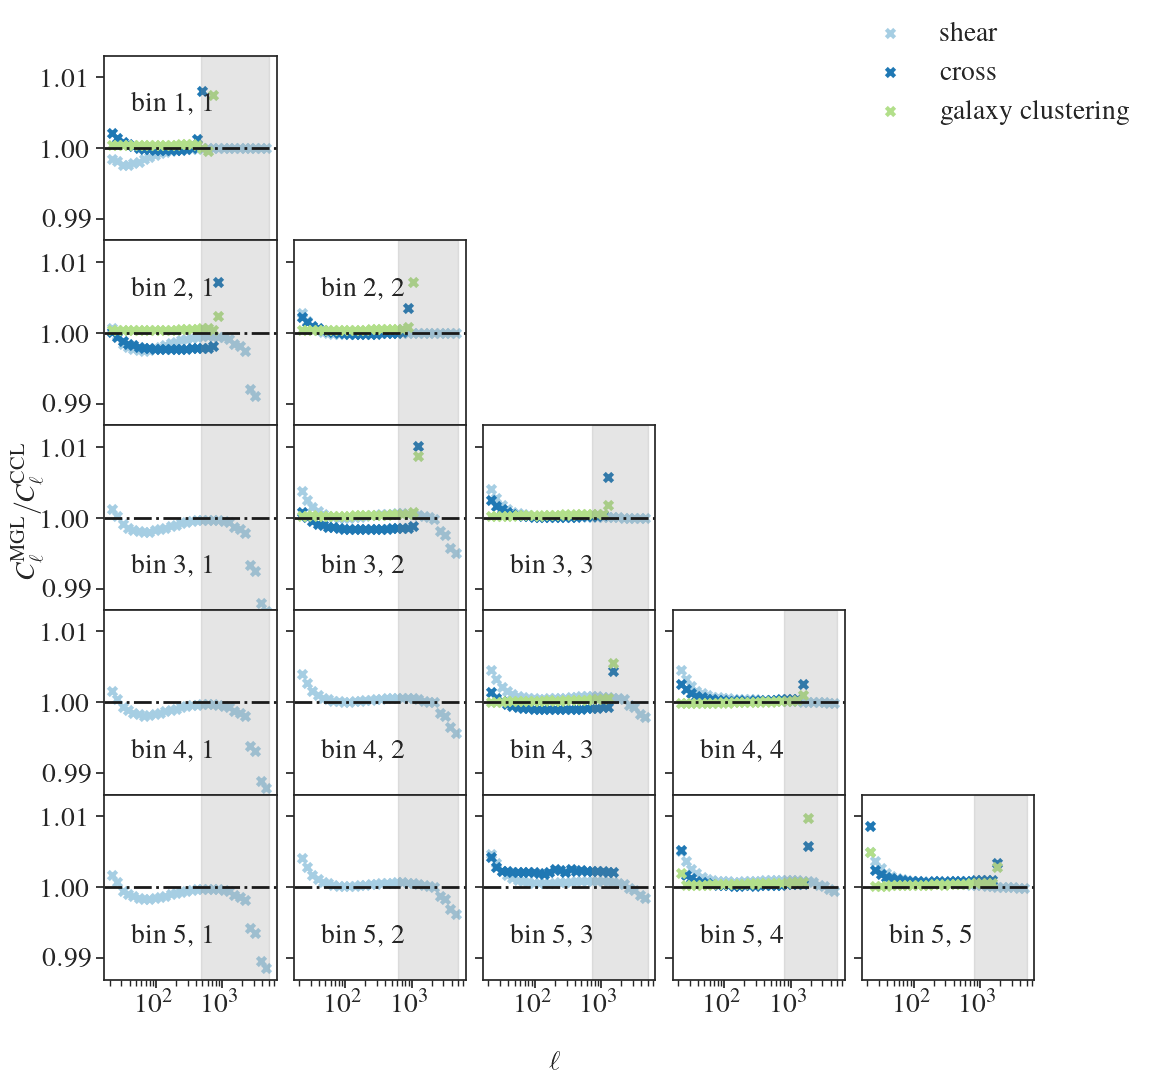

In [16]:
nbin=5
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i,j].scatter(ell_l, cl_wl_mgl[:,i,j]/cl_wl_ccl[:, i, j], marker='x')
            ax[i,j].scatter(ell_x, cl_lenssource_mgl[:,i,j]/cl_lenssource_ccl[:, i, j], marker='x')
            ax[i,j].scatter(ell_g, cl_gc_mgl[:,i,j]/cl_gc_ccl[:, i, j], marker='x')
            ax[i, j].set_ylim(0.987, 1.013)
            #ax[i, j].set_ylim(0.955, 1.045)
            ax[i,j].text(.4, .7, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)  if i<2 else ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axhline(y=1, linestyle='-.', linewidth=2, color='k')
            #ax[i, j].axvspan(xmin=l_wl_max[i, j], xmax=l_wl[-1], color='grey', alpha=0.1)
            ax[i,j].set_xscale('log')
            ax[i,j].axvspan(5000, kmax07[j], color='grey', alpha=0.2, label='_nolegend_') #GG cuts
        else:
            ax[i,j].axis('off')       
fig.text(0.06, 0.5, r'$C^{\rm MGL}_\ell/C^{\rm CCL}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend(['shear', 'cross', 'galaxy clustering'], loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False)

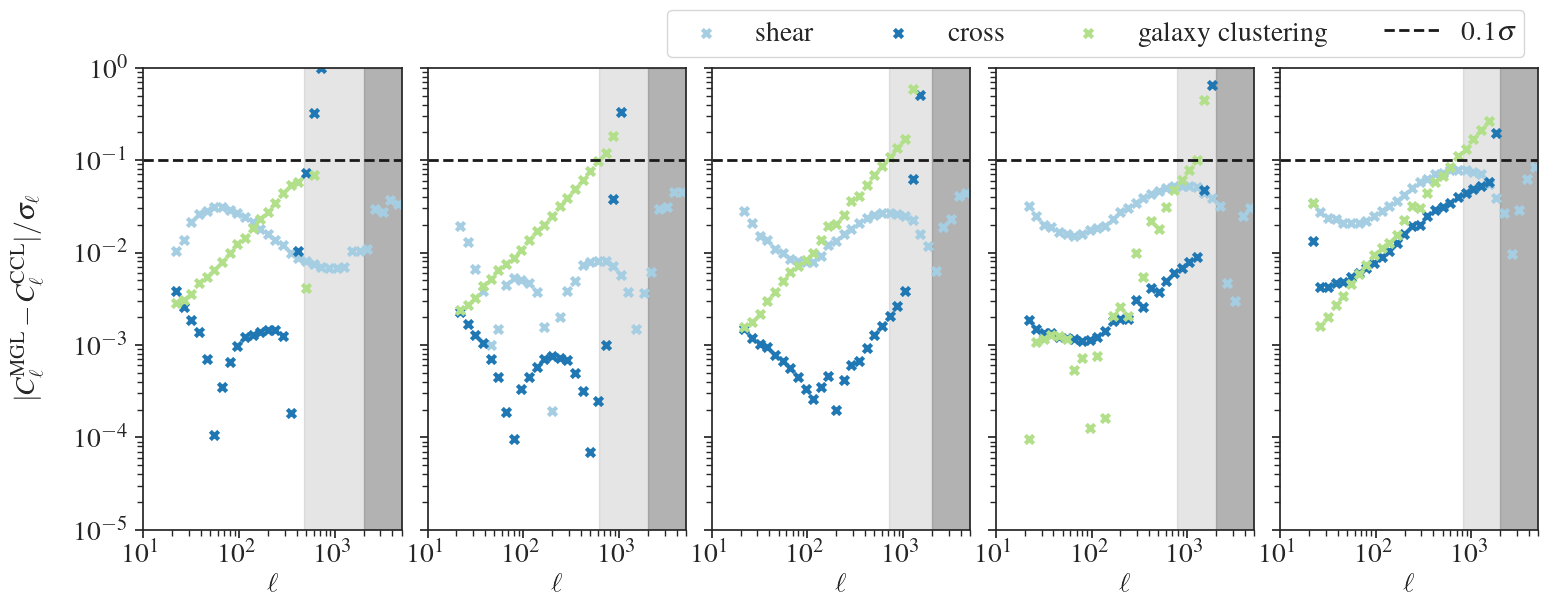

In [17]:
fig, ax = plt.subplots(1, nbin, figsize=(18, 6), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    ax[i].axvspan(5000, kmax07[i], color='grey', alpha=0.2, label='_nolegend_') #GG cuts  
    ax[i].axvspan(5000, 2000, color='grey', alpha=0.5, label='_nolegend_') 
    ax[i].scatter(ell_l, abs(cl_wl_mgl[:,i,i]-cl_wl_ccl[:, i, i])/err_cl_wl[:, i, i], marker='x')
    ax[i].scatter(ell_x, abs(cl_lenssource_mgl[:,i,i]-cl_lenssource_ccl[:, i, i])/err_cl_xc[:, i, i], marker='x')
    ax[i].scatter(ell_g, abs(cl_gc_mgl[:,i,i]-cl_gc_ccl[:, i, i])/err_cl_gc[:, i, i], marker='x')
    ax[i].axhline(y=0.1, color='k', linestyle='--', linewidth=2)
    ax[i].set_ylim(0.00001, 1.)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlim(10, 5000)
    ax[i].set_xlabel(r'$\ell$', fontsize=20)
fig.text(0.06, 0.5, r'$|C^{\rm MGL}_\ell-C^{\rm CCL}_\ell|/\sigma_\ell$', ha='center', va='center', rotation='vertical', fontsize=20) 
fig.legend(['shear', 'cross', 'galaxy clustering', '$0.1 \sigma$']
#'shear', 'cross', 'galaxy clustering',]
, loc='upper right', ncol=4, bbox_to_anchor=(0.9,1), bbox_transform=fig.transFigure, fontsize=20, frameon=True)

# Compute $\chi^2$

In [18]:
def compute_data_vector_3x2pt(cl_ll, cl_gg, cl_lg, cl_gl):
        """This function calculates the 3x2pt angular power spectra and constructs a data vector
        by combining the power spectra for different bins. It then applies a mask to the data
        vector based on the survey's scale-cuts per photo-z bin.

        Parameters:
        ----------
        params_dic : dict
            Dictionary containing the parameters required for computing the 3x2pt angular power spectra.

        Returns:
        -------
        data_vector_masked : numpy.ndarray
            The masked data vector containing the 3x2pt angular power spectra for the given parameters.
        """
        data_vector = np.zeros((MGL.Survey.nell_wl*MGL.Survey.nbin_flat_s+MGL.Survey.nell_gc*MGL.Survey.nbin_flat_l+MGL.Survey.nell_xc*MGL.Survey.nbin_s*MGL.Survey.nbin_l), 'float64')
        # construct a vector
        idx_start = 0
        start_xc = MGL.Survey.nell_wl*MGL.Survey.nbin_flat_s
        start_gc = start_xc+MGL.Survey.nell_xc*MGL.Survey.nbin_s*MGL.Survey.nbin_l   
        for bin1 in range(MGL.Survey.nbin_s):
            for bin2 in range(bin1, MGL.Survey.nbin_s):
                data_vector[idx_start*MGL.Survey.nell_wl:(idx_start+1)*MGL.Survey.nell_wl] = cl_ll[:, bin1, bin2]
                idx_start += 1
        idx_start = 0        
        for bin1 in range(MGL.Survey.nbin_l):
            for bin2 in range(bin1, MGL.Survey.nbin_l):
                data_vector[idx_start*MGL.Survey.nell_gc+start_gc:(idx_start+1)*MGL.Survey.nell_gc+start_gc] = cl_gg[:, bin1, bin2]
                idx_start += 1
        idx_start = 0
        for bin1 in range(MGL.Survey.nbin_l):
            for bin2 in range(MGL.Survey.nbin_s):
                # for direct comparison with cosmosis:
                data_vector[idx_start*MGL.Survey.nell_xc+start_xc:(idx_start+1)*MGL.Survey.nell_xc+start_xc] = cl_gl[:, bin1, bin2]
                idx_start += 1
        # apply mask for different scale-cuts per photo-z bin        
        data_vector_masked = data_vector[MGL.Survey.mask_data_vector_3x2pt]
        return data_vector_masked

In [19]:
mgl_datavector = compute_data_vector_3x2pt(cl_wl_mgl, cl_gc_mgl, cl_sourcelens_mgl, cl_lenssource_mgl)

In [20]:
ccl_datavector = compute_data_vector_3x2pt(cl_wl_ccl, cl_gc_ccl, cl_sourcelens_ccl, cl_lenssource_ccl)

In [21]:
difference_vector = mgl_datavector - ccl_datavector

In [22]:
inv_data_covariance = np.linalg.inv(MGL.Data.data_covariance)

In [23]:
chi2 = np.einsum('i, ij, j->', difference_vector, inv_data_covariance, difference_vector)  

In [24]:
chi2

0.2494458089912262